# Factorization Machine Feature Ablation Study
This notebook assumes you already have a working `FactorizationMachine` class from the previous notebook.

The goal is to compare different feature combinations while leaving the model implementation unchanged.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy


## 2. Load MovieLens 100K

In [2]:
column_names = ["user_id","movie_id","rating","timestamp"]

train = pd.read_csv("data/u1.base", sep="\t", names=column_names)
test  = pd.read_csv("data/u1.test", sep="\t", names=column_names)

users = pd.read_csv(
    "data/u.user",
    sep="|",
    names=["user_id","age","gender","occupation","zip_code"],
    encoding="latin-1"
)

genre_columns = [
    "unknown","Action","Adventure","Animation","Children","Comedy",
    "Crime","Documentary","Drama","Fantasy","Film-Noir","Horror",
    "Musical","Mystery","Romance","Sci-Fi","Thriller","War","Western"
]

movie_columns = [
    "movie_id","title","release_date","video_release","imdb_url"
] + genre_columns

movies = pd.read_csv(
    "data/u.item",
    sep="|",
    names=movie_columns,
    encoding="latin-1"
)


## 3. Merge training metadata

In [3]:
train_df = train.merge(users,on="user_id").merge(movies,on="movie_id")

bins=[0,18,25,35,45,50,60,100]
labels=["0-18","19-25","26-35","36-45","46-50","51-60","60+"]

train_df["age_group"]=pd.cut(train_df["age"],bins=bins,labels=labels)
users["age_group"]=pd.cut(users["age"],bins=bins,labels=labels)


## 4. Feature builder

In [4]:
def build_objects(config):

    feature_to_idx={}
    counter=0

    def add(name):
        nonlocal counter
        if name not in feature_to_idx:
            feature_to_idx[name]=counter
            counter+=1

    for _,row in train_df.iterrows():

        if config["user"]:
            add(f"user_{row.user_id}")

        if config["movie"]:
            add(f"movie_{row.movie_id}")

        if config["gender"]:
            add(f"gender_{row.gender}")

        if config["occupation"]:
            add(f"occupation_{row.occupation}")

        if config["age"]:
            add(f"age_{row.age_group}")

        if config["genres"]:
            for g in genre_columns:
                if row[g]==1:
                    add(f"genre_{g}")

    training_samples=[]

    for _,row in train_df.iterrows():

        feats=[]

        if config["user"]:
            feats.append(feature_to_idx[f"user_{row.user_id}"])

        if config["movie"]:
            feats.append(feature_to_idx[f"movie_{row.movie_id}"])

        if config["gender"]:
            feats.append(feature_to_idx[f"gender_{row.gender}"])

        if config["occupation"]:
            feats.append(feature_to_idx[f"occupation_{row.occupation}"])

        if config["age"]:
            feats.append(feature_to_idx[f"age_{row.age_group}"])

        if config["genres"]:
            for g in genre_columns:
                if row[g]==1:
                    feats.append(feature_to_idx[f"genre_{g}"])

        training_samples.append((feats,row.rating))

    user_features={}

    for _,row in users.iterrows():

        key=f"user_{row.user_id}"
        if config["user"] and key not in feature_to_idx:
            continue

        feats=[]

        if config["user"]:
            feats.append(feature_to_idx[key])

        if config["gender"]:
            feats.append(feature_to_idx[f"gender_{row.gender}"])

        if config["occupation"]:
            feats.append(feature_to_idx[f"occupation_{row.occupation}"])

        if config["age"]:
            feats.append(feature_to_idx[f"age_{row.age_group}"])

        user_features[row.user_id]=feats

    movie_features={}

    for _,row in movies.iterrows():

        key=f"movie_{row.movie_id}"
        if config["movie"] and key not in feature_to_idx:
            continue

        feats=[]

        if config["movie"]:
            feats.append(feature_to_idx[key])

        if config["genres"]:
            for g in genre_columns:
                if row[g]==1:
                    gk=f"genre_{g}"
                    if gk in feature_to_idx:
                        feats.append(feature_to_idx[gk])

        movie_features[row.movie_id]=feats

    return feature_to_idx,training_samples,user_features,movie_features


## 5. Paste your `FactorizationMachine` class below this cell

In [5]:
class FactorizationMachine:

    def __init__(
        self,
        num_features,
        user_features,
        movie_features,
        k=20,
        learning_rate=0.01,
        reg=0.02
    ):

        self.num_features = num_features
        
        self.user_features = user_features
        self.movie_features = movie_features
        
        self.k = k

        self.learning_rate = learning_rate
        self.reg = reg

        # Global Bias
        self.w0 = 0.0

        # Linear Weights
        self.w = np.zeros(num_features)

        # Feature Embeddings
        self.V = np.random.normal(
            0,
            0.01,
            (num_features, k)
        )
    
    
    def predict(
    self,
    feature_indices
    ):
        prediction = self.w0
    
        # Linear Part
        for feature in feature_indices:
        
            prediction += self.w[
                feature
            ]
    
        # Interaction Part
        V = self.V[np.array(feature_indices)]

        sum1 = np.sum(V, axis=0)

        sum2 = np.sum(V * V, axis=0)

        interaction = 0.5 * np.sum(
            sum1**2 - sum2
        )

        prediction += interaction
    
        return float(np.clip(prediction, 1, 5))
    

    def sgd_step(
        self,
        feature_indices,
        rating
    ):

        prediction = self.predict(
            feature_indices
        )

        error = rating - prediction

        # Global bias
        self.w0 += (
            self.learning_rate * error
        )

        # Linear weights
        for feature in feature_indices:

            self.w[feature] += (
                self.learning_rate
                * (
                    error
                    -
                    self.reg
                    * self.w[feature]
                )
            )

        # Sum of embeddings
        sum_v = np.zeros(self.k)

        for feature in feature_indices:

            sum_v += self.V[feature]

        # Update embeddings
        for feature in feature_indices:

            gradient = (
                sum_v
                -
                self.V[feature]
            )

            self.V[feature] += (

                self.learning_rate
                * (
                    error * gradient

                    -

                    self.reg
                    * self.V[feature]
                )

            )

        return error

    def fit(
        self,
        training_samples,
        epochs=20
    ):
    
        print("Training Factorization Machine...")
    
        for epoch in range(epochs):
        
            np.random.shuffle(
                training_samples
            )
    
            squared_errors = []
    
            for feature_indices, rating in training_samples:
            
                error = self.sgd_step(
                    feature_indices,
                    rating
                )
    
                squared_errors.append(
                    error ** 2
                )
    
            rmse = np.sqrt(
                np.mean(
                    squared_errors
                )
            )
    
            print(
                f"Epoch {epoch+1:2d}/{epochs}"
                f" | RMSE = {rmse:.4f}"
            )    

    def build_feature_vector(
        self,
        user_id,
        movie_id
    ):

        return [*self.user_features[user_id],*self.movie_features[movie_id]]


    def predict_rating(
        self,
        user_id,
        movie_id
    ):

        feature_indices = self.build_feature_vector(
            user_id,
            movie_id
        )

        return self.predict(
            feature_indices
        )


    def evaluate(
        self,
        test_df
    ):

        predictions = []

        squared_errors = []

        absolute_errors = []

        for row in test_df.itertuples(index=False):

            if (
                row.user_id not in self.user_features
                or
                row.movie_id not in self.movie_features
            ):
                continue

            predicted = self.predict_rating(
                row.user_id,
                row.movie_id
            )
            if np.isnan(predicted):
                continue

            error = abs(
                row.rating - predicted
            )

            predictions.append(
                (
                    row.user_id,
                    row.movie_id,
                    row.rating,
                    predicted,
                    error
                )
            )

            absolute_errors.append(error)
            squared_errors.append(error**2)

        prediction_df = pd.DataFrame(
            predictions,
            columns=[
                "user_id",
                "movie_id",
                "actual",
                "predicted",
                "error"
            ]
        )

        mae = np.mean(
            absolute_errors
        )

        rmse = np.sqrt(
            np.mean(
                squared_errors
            )
        )

        return prediction_df, rmse, mae


    def recommend(
        self,
        user_id,
        train_df,
        top_n=10
    ):

        watched = set(

            train_df.loc[
                train_df.user_id == user_id,
                "movie_id"
            ]

        )

        recommendations = []

        for movie_id in self.movie_features:

            if movie_id in watched:
                continue

            prediction = self.predict_rating(
                user_id,
                movie_id
            )

            recommendations.append(
                (
                    movie_id,
                    prediction
                )
            )

        recommendations.sort(
            key=lambda x: x[1],
            reverse=True
        )

        return pd.DataFrame(
            recommendations[:top_n],
            columns=[
                "movie_id",
                "predicted_rating"
            ]
        )

## 7. Run Ablation

In [6]:
def experiment(configs):
    results=[]

    for name,config in configs.items():

        print("="*60)
        print(name)

        feature_to_idx,training_samples,user_features,movie_features = build_objects(config)

        fm = FactorizationMachine(
            num_features=len(feature_to_idx),
            user_features=user_features,
            movie_features=movie_features,
            k=20,
            learning_rate=0.01,
            reg=0.02
        )

        fm.fit(training_samples,epochs=20)

        prediction_df,rmse,mae=fm.evaluate(test)

        results.append({
            "Features":name,
            "MAE":mae,
            "RMSE":rmse
        })

    results=pd.DataFrame(results)
    return results


## 8. Visualization

In [7]:
def plot_results(results):
    plt.figure(figsize=(8,4))
    plt.plot(results["Features"],results["RMSE"],marker="o")
    plt.xticks(rotation=20)
    plt.ylabel("RMSE")
    plt.title("Feature Ablation Study")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(results["Features"],results["MAE"],marker="o")
    plt.xticks(rotation=20)
    plt.ylabel("MAE")
    plt.title("Feature Ablation Study")
    plt.grid(True)
    plt.show()

    results.sort_values("RMSE")


# Experiments


User + Movie
Training Factorization Machine...
Epoch  1/20 | RMSE = 1.0205
Epoch  2/20 | RMSE = 0.9574
Epoch  3/20 | RMSE = 0.9421
Epoch  4/20 | RMSE = 0.9349
Epoch  5/20 | RMSE = 0.9306
Epoch  6/20 | RMSE = 0.9278
Epoch  7/20 | RMSE = 0.9258
Epoch  8/20 | RMSE = 0.9244
Epoch  9/20 | RMSE = 0.9231
Epoch 10/20 | RMSE = 0.9223
Epoch 11/20 | RMSE = 0.9210
Epoch 12/20 | RMSE = 0.9198
Epoch 13/20 | RMSE = 0.9184
Epoch 14/20 | RMSE = 0.9160
Epoch 15/20 | RMSE = 0.9129
Epoch 16/20 | RMSE = 0.9079
Epoch 17/20 | RMSE = 0.9017
Epoch 18/20 | RMSE = 0.8940
Epoch 19/20 | RMSE = 0.8845
Epoch 20/20 | RMSE = 0.8745
+ Gender
Training Factorization Machine...
Epoch  1/20 | RMSE = 1.0173
Epoch  2/20 | RMSE = 0.9540
Epoch  3/20 | RMSE = 0.9398
Epoch  4/20 | RMSE = 0.9323
Epoch  5/20 | RMSE = 0.9264
Epoch  6/20 | RMSE = 0.9215
Epoch  7/20 | RMSE = 0.9171
Epoch  8/20 | RMSE = 0.9127
Epoch  9/20 | RMSE = 0.9087
Epoch 10/20 | RMSE = 0.9042
Epoch 11/20 | RMSE = 0.8999
Epoch 12/20 | RMSE = 0.8957
Epoch 13/20 | 

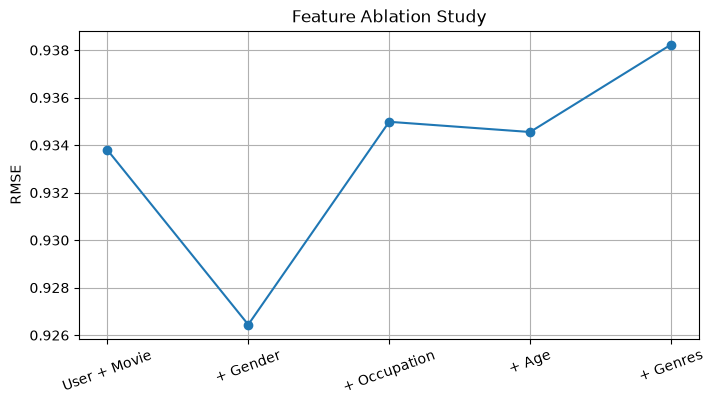

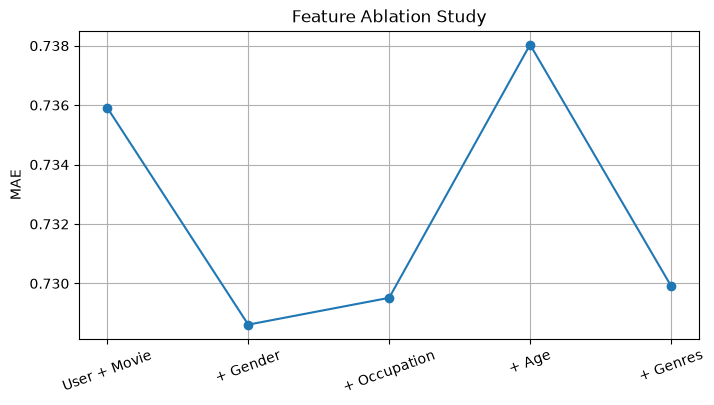

In [8]:
configs = {
    "User + Movie":{
        "user":True,"movie":True,
        "gender":False,"occupation":False,
        "age":False,"genres":False
    },
    "+ Gender":{
        "user":True,"movie":True,
        "gender":True,"occupation":False,
        "age":False,"genres":False
    },
    "+ Occupation":{
        "user":True,"movie":True,
        "gender":True,"occupation":True,
        "age":False,"genres":False
    },
    "+ Age":{
        "user":True,"movie":True,
        "gender":True,"occupation":True,
        "age":True,"genres":False
    },
    "+ Genres":{
        "user":True,"movie":True,
        "gender":True,"occupation":True,
        "age":True,"genres":True
    }
}
results = experiment(configs)
plot_results(results)

User + Movie
Training Factorization Machine...
Epoch  1/20 | RMSE = 1.0205
Epoch  2/20 | RMSE = 0.9571
Epoch  3/20 | RMSE = 0.9423
Epoch  4/20 | RMSE = 0.9349
Epoch  5/20 | RMSE = 0.9306
Epoch  6/20 | RMSE = 0.9280
Epoch  7/20 | RMSE = 0.9259
Epoch  8/20 | RMSE = 0.9241
Epoch  9/20 | RMSE = 0.9233
Epoch 10/20 | RMSE = 0.9219
Epoch 11/20 | RMSE = 0.9209
Epoch 12/20 | RMSE = 0.9194
Epoch 13/20 | RMSE = 0.9173
Epoch 14/20 | RMSE = 0.9146
Epoch 15/20 | RMSE = 0.9104
Epoch 16/20 | RMSE = 0.9047
Epoch 17/20 | RMSE = 0.8973
Epoch 18/20 | RMSE = 0.8893
Epoch 19/20 | RMSE = 0.8805
Epoch 20/20 | RMSE = 0.8707
+ Gender
Training Factorization Machine...
Epoch  1/20 | RMSE = 1.0196
Epoch  2/20 | RMSE = 0.9554
Epoch  3/20 | RMSE = 0.9406
Epoch  4/20 | RMSE = 0.9328
Epoch  5/20 | RMSE = 0.9269
Epoch  6/20 | RMSE = 0.9222
Epoch  7/20 | RMSE = 0.9181
Epoch  8/20 | RMSE = 0.9137
Epoch  9/20 | RMSE = 0.9096
Epoch 10/20 | RMSE = 0.9055
Epoch 11/20 | RMSE = 0.9015
Epoch 12/20 | RMSE = 0.8968
Epoch 13/20 | 

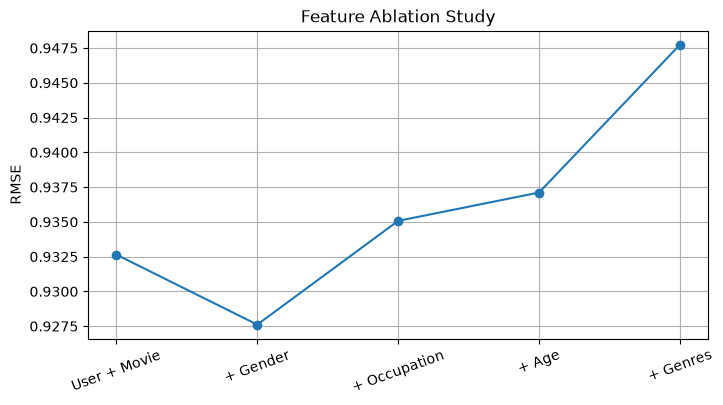

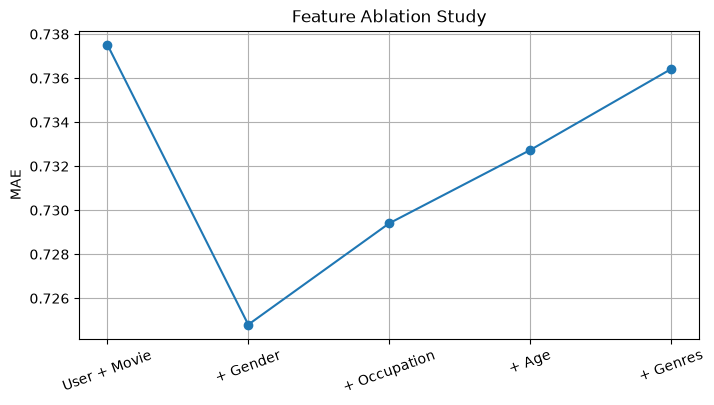

In [9]:
results = experiment(configs)
plot_results(results)

In [10]:
config = {
    "user": True,
    "movie": True,
    "gender": True,
    "occupation": True,
    "age": True,
    "genres": True
}
feature_to_idx, training_samples, user_features, movie_features = build_objects(config)
epochs_to_try = [
    5,
    10,
    20,
    40,
    60,
    80,
    100
]
results = []

for epochs in epochs_to_try:

    print("=" * 60)
    print(f"Training with {epochs} epochs")

    fm = FactorizationMachine(
        num_features=len(feature_to_idx),
        user_features=user_features,
        movie_features=movie_features,
        k=20,
        learning_rate=0.01,
        reg=0.02
    )

    fm.fit(
        training_samples,
        epochs=epochs
    )

    prediction_df, rmse, mae = fm.evaluate(test)

    results.append({
        "Epochs": epochs,
        "MAE": mae,
        "RMSE": rmse
    })

Training with 5 epochs
Training Factorization Machine...
Epoch  1/5 | RMSE = 1.0171
Epoch  2/5 | RMSE = 0.9589
Epoch  3/5 | RMSE = 0.9415
Epoch  4/5 | RMSE = 0.9296
Epoch  5/5 | RMSE = 0.9187
Training with 10 epochs
Training Factorization Machine...
Epoch  1/10 | RMSE = 1.0179
Epoch  2/10 | RMSE = 0.9588
Epoch  3/10 | RMSE = 0.9411
Epoch  4/10 | RMSE = 0.9292
Epoch  5/10 | RMSE = 0.9187
Epoch  6/10 | RMSE = 0.9082
Epoch  7/10 | RMSE = 0.8984
Epoch  8/10 | RMSE = 0.8879
Epoch  9/10 | RMSE = 0.8797
Epoch 10/10 | RMSE = 0.8704
Training with 20 epochs
Training Factorization Machine...
Epoch  1/20 | RMSE = 1.0178
Epoch  2/20 | RMSE = 0.9594
Epoch  3/20 | RMSE = 0.9420
Epoch  4/20 | RMSE = 0.9300
Epoch  5/20 | RMSE = 0.9193
Epoch  6/20 | RMSE = 0.9090
Epoch  7/20 | RMSE = 0.8993
Epoch  8/20 | RMSE = 0.8897
Epoch  9/20 | RMSE = 0.8797
Epoch 10/20 | RMSE = 0.8708
Epoch 11/20 | RMSE = 0.8625
Epoch 12/20 | RMSE = 0.8537
Epoch 13/20 | RMSE = 0.8448
Epoch 14/20 | RMSE = 0.8368
Epoch 15/20 | RMSE =

In [11]:
results = pd.DataFrame(results)

results

,Epochs,MAE,RMSE
0,5,0.747083,0.949501
1,10,0.733222,0.941516
2,20,0.734212,0.947071
3,40,0.758592,0.978184
4,60,0.782145,1.012687
5,80,0.797836,1.032901
6,100,0.795559,1.043849


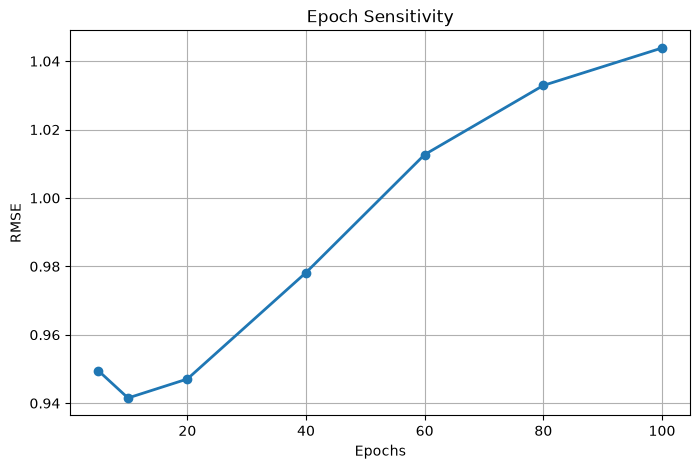

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    results["Epochs"],
    results["RMSE"],
    marker="o",
    linewidth=2
)

plt.xlabel("Epochs")
plt.ylabel("RMSE")
plt.title("Epoch Sensitivity")
plt.grid(True)

plt.show()

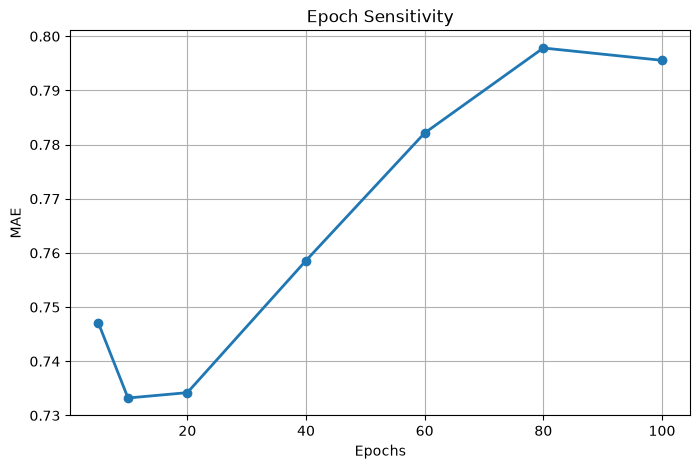

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    results["Epochs"],
    results["MAE"],
    marker="o",
    linewidth=2
)

plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.title("Epoch Sensitivity")
plt.grid(True)

plt.show()

In [14]:
results.sort_values("RMSE")

,Epochs,MAE,RMSE
1,10,0.733222,0.941516
2,20,0.734212,0.947071
0,5,0.747083,0.949501
3,40,0.758592,0.978184
4,60,0.782145,1.012687
5,80,0.797836,1.032901
6,100,0.795559,1.043849
